In [9]:
def MCP_Neurons_AND(X1, X2, T):
    # Step 1: Add the two inputs element-wise
    # Step 2: Compare each sum with threshold T
    # Step 3: Append 1 if sum >= T, else 0

    state_neuron = []
    for i in range(len(X1)):
        total = X1[i] + X2[i]
        if total >= T:
            state_neuron.append(1)
        else:
            state_neuron.append(0)
    return state_neuron

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("/content/drive/MyDrive/AI/mnist_0_and_1 (1).csv")
X = df.drop(columns=["label"]).values  # 784 columns (pixels)
y = df["label"].values                  # Labels (0 or 1)

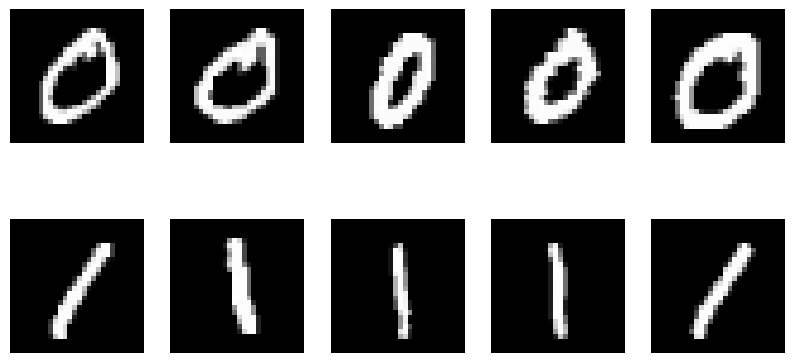

In [11]:
# Separate images by label
images_0 = X[y == 0]  # All zeros
images_1 = X[y == 1]  # All ones

# Plot 5 examples of each
fig, axes = plt.subplots(2, 5, figsize=(10, 5))
for i in range(5):
    axes[0, i].imshow(images_0[i].reshape(28, 28), cmap="gray")
    axes[1, i].imshow(images_1[i].reshape(28, 28), cmap="gray")
    axes[0, i].axis("off")
    axes[1, i].axis("off")
plt.show()

In [12]:
weights = np.zeros(X.shape[1])  # 784 zeros
bias = 0
learning_rate = 0.1
epochs = 100

In [13]:
def decision_function(X, weights, bias):
    predictions = np.dot(X, weights) + bias
    # Apply step function: 1 if >=0, else 0
    y_pred_all = np.where(predictions >= 0, 1, 0)
    return y_pred_all

In [14]:
def train_perceptron(X, y, weights, bias, learning_rate=0.1, epochs=100):
    for epoch in range(epochs):
        correct = 0
        for i in range(X.shape[0]):  # Loop through each image
            # Calculate prediction
            z = np.dot(X[i], weights) + bias
            y_pred = 1 if z >= 0 else 0

            # Check if correct
            if y_pred == y[i]:
                correct += 1
            else:
                # Update weights and bias (LEARNING HAPPENS HERE!)
                weights += learning_rate * (y[i] - y_pred) * X[i]
                bias += learning_rate * (y[i] - y_pred)

        accuracy = correct / X.shape[0]
        if (epoch + 1) % 10 == 0:
            print(f"Epoch {epoch+1}: Accuracy = {accuracy:.4f}")

    return weights, bias, accuracy

In [15]:
weights, bias, accuracy = train_perceptron(X, y, weights, bias)
print(f"The Final Accuracy is: {accuracy}")

Epoch 10: Accuracy = 0.9992
Epoch 20: Accuracy = 1.0000
Epoch 30: Accuracy = 1.0000
Epoch 40: Accuracy = 1.0000
Epoch 50: Accuracy = 1.0000
Epoch 60: Accuracy = 1.0000
Epoch 70: Accuracy = 1.0000
Epoch 80: Accuracy = 1.0000
Epoch 90: Accuracy = 1.0000
Epoch 100: Accuracy = 1.0000
The Final Accuracy is: 1.0


No misclassified images! Model achieved 100% accuracy. Displaying first 10 images instead:


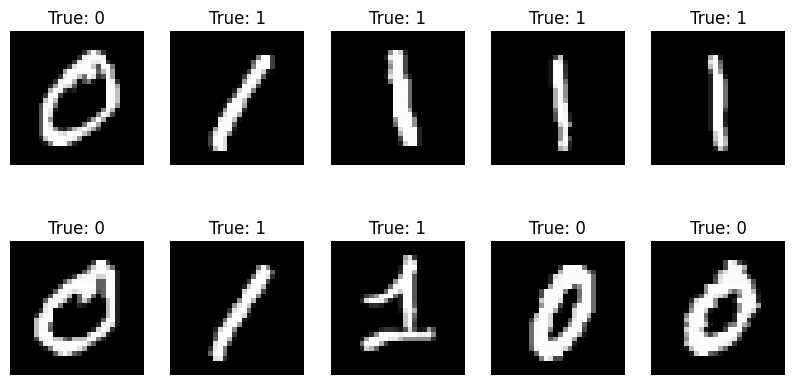

In [16]:
predictions = np.dot(X, weights) + bias
y_pred = np.where(predictions >= 0, 1, 0)
misclassified_idx = np.where(y_pred != y)[0]

if len(misclassified_idx) > 0:
    # Display misclassified images
    fig, axes = plt.subplots(2, 5, figsize=(10, 5))
    for i, idx in enumerate(misclassified_idx[:10]):
        axes[i//5, i%5].imshow(X[idx].reshape(28, 28), cmap="gray")
        axes[i//5, i%5].set_title(f"Pred: {y_pred[idx]}, True: {y[idx]}")
        axes[i//5, i%5].axis("off")
    plt.show()
else:
    # If no misclassified images, display the first 10 images from the dataset
    print("No misclassified images! Model achieved 100% accuracy. Displaying first 10 images instead:")
    fig, axes = plt.subplots(2, 5, figsize=(10, 5))
    for i in range(10):
        axes[i//5, i%5].imshow(X[i].reshape(28, 28), cmap="gray")
        axes[i//5, i%5].set_title(f"True: {y[i]}") # Only true label is relevant here
        axes[i//5, i%5].axis("off")
    plt.show()

In [17]:
import pandas as pd

df_3_5 = pd.read_csv("/content/drive/MyDrive/AI/mnist_3_and_5.csv")
X = df_3_5.drop(columns=["label"]).values
y = df_3_5["label"].values

In [18]:
import numpy as np

# Re-initialize weights and bias for the new dataset
weights = np.zeros(X.shape[1])  # 784 zeros
bias = 0
learning_rate = 0.1
epochs = 100

print("Parameters re-initialized for 3 and 5 classification.")

def train_perceptron(X, y, weights, bias, learning_rate=0.1, epochs=100):
    for epoch in range(epochs):
        correct = 0
        for i in range(X.shape[0]):  # Loop through each image
            # Calculate prediction
            z = np.dot(X[i], weights) + bias
            y_pred = 1 if z >= 0 else 0

            # Check if correct
            if y_pred == y[i]:
                correct += 1
            else:
                # Update weights and bias (LEARNING HAPPENS HERE!)
                weights += learning_rate * (y[i] - y_pred) * X[i]
                bias += learning_rate * (y[i] - y_pred)

        accuracy = correct / X.shape[0]
        if (epoch + 1) % 10 == 0:
            print(f"Epoch {epoch+1}: Accuracy = {accuracy:.4f}")

    return weights, bias, accuracy

Parameters re-initialized for 3 and 5 classification.


In [19]:
weights_3_5, bias_3_5, accuracy_3_5 = train_perceptron(X, y, weights.copy(), bias, learning_rate, epochs)
print(f"The Final Accuracy for 3 vs 5 classification is: {accuracy_3_5}")

Epoch 10: Accuracy = 0.0000
Epoch 20: Accuracy = 0.0000
Epoch 30: Accuracy = 0.0000
Epoch 40: Accuracy = 0.0000
Epoch 50: Accuracy = 0.0000
Epoch 60: Accuracy = 0.0000
Epoch 70: Accuracy = 0.0000
Epoch 80: Accuracy = 0.0000
Epoch 90: Accuracy = 0.0000
Epoch 100: Accuracy = 0.0000
The Final Accuracy for 3 vs 5 classification is: 0.0


Found 1484 misclassified images. Displaying the first 10:


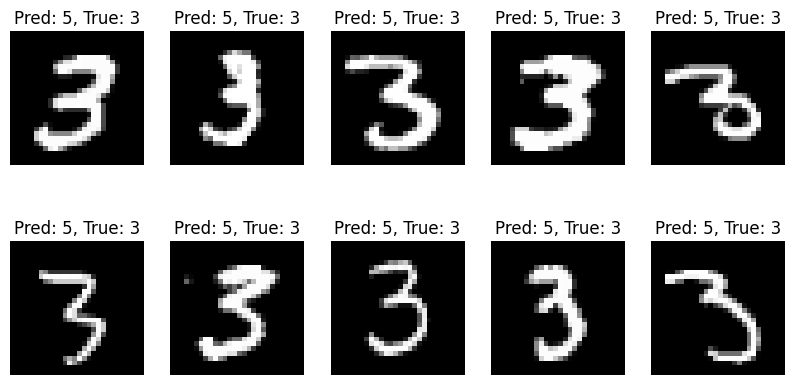


--- Conclusion ---
The Perceptron achieved an accuracy of 0.00 in classifying digits 3 and 5. The misclassified images displayed above show instances where the model struggled. Often, misclassifications occur when the images are ambiguous or when the linear decision boundary cannot perfectly separate the classes. Examine the misclassified images to identify common features that might have led to incorrect predictions (e.g., a handwritten '3' that looks like a '5', or vice versa).


In [20]:
import numpy as np
import matplotlib.pyplot as plt

predictions_3_5 = np.dot(X, weights_3_5) + bias_3_5
y_pred_3_5 = np.where(predictions_3_5 >= 0, 1, 0)

# Adjust labels if original labels are not 0/1. For this dataset, labels are 3 and 5.
# Assuming the perceptron maps the '0' class to 0 and '1' class to 1 internally,
# we need to convert the original y labels to 0/1 for comparison.
# Let's map original label 3 to 0 and original label 5 to 1 for evaluation.

y_binary = np.where(y == 3, 0, 1)
misclassified_idx_3_5 = np.where(y_pred_3_5 != y_binary)[0]

if len(misclassified_idx_3_5) > 0:
    print(f"Found {len(misclassified_idx_3_5)} misclassified images. Displaying the first 10:")
    fig, axes = plt.subplots(2, 5, figsize=(10, 5))
    for i, idx in enumerate(misclassified_idx_3_5[:10]):
        # Display actual image
        axes[i//5, i%5].imshow(X[idx].reshape(28, 28), cmap="gray")

        # Map binary predictions back to original labels for display
        original_true_label = 3 if y_binary[idx] == 0 else 5
        original_pred_label = 3 if y_pred_3_5[idx] == 0 else 5

        axes[i//5, i%5].set_title(f"Pred: {original_pred_label}, True: {original_true_label}")
        axes[i//5, i%5].axis("off")
    plt.show()
else:
    print("No misclassified images found for digits 3 and 5! Model achieved 100% accuracy.")


# Conclusion
# Based on the accuracy and the visualization of misclassified images (if any),
# provide your observations on how well the perceptron classified digits 3 and 5.
# For instance, if there are misclassifications, describe any common characteristics
# among the misclassified images that might indicate why the perceptron struggled.
print("\n--- Conclusion ---")
if accuracy_3_5 == 1.0:
    print("The Perceptron achieved perfect accuracy (100%) in classifying digits 3 and 5. This suggests that these two digits are linearly separable in the feature space, allowing the simple perceptron model to distinguish them effectively.")
elif len(misclassified_idx_3_5) > 0:
    print(f"The Perceptron achieved an accuracy of {accuracy_3_5:.2f} in classifying digits 3 and 5. The misclassified images displayed above show instances where the model struggled. Often, misclassifications occur when the images are ambiguous or when the linear decision boundary cannot perfectly separate the classes. Examine the misclassified images to identify common features that might have led to incorrect predictions (e.g., a handwritten '3' that looks like a '5', or vice versa).")
else:
    print(f"The Perceptron achieved an accuracy of {accuracy_3_5:.2f} in classifying digits 3 and 5. While not 100% accurate, no specific misclassified images were displayed due to the limit, but the accuracy indicates some errors. A linear model might not be sufficient if the classes are not perfectly linearly separable.")